### Assignment 2: Using NLP to Understand Online Reviews

**Motivation:**

Online shopping is growing so fast that the global online shopping market size is predicted to hit 4 trillion in 2020. And in the US alone, we’re expecting to have 300 million online shoppers in 2023. That’s 91% of the entire country’s population!

So far, 69% of Americans have shopped online, and 25% of Americans shop online at least once per month. The majority (59%) of these shoppers bought clothing items, and 47% bought their first item on Amazon.

But Americans aren’t the only ones who shop online. People all over the world understand the benefits. According to optinmonster.com, the countries with the leading average eCommerce revenue per shoppers are: 

USA (\\$1,804), UK (\\$1,629), Sweden (\\$1,446), France (\\$1,228), Germany (\\$1,064), Japan (\\$968), Spain (\\$849), China (\\$626), Russia (\\$396), and Brazil (\\$350).

Given the size of eCommerce in household shopping transactions, it is important to understand how eCommerce giants are able to offer shoppers all the information they need to make a purchase. One of the pillars of online shopping is online reviews. Online reviews posted by the previous shoppers serve as a great source of information for the new shoppers. Almost all of the eCommerce websites collect and post previous shoppers reviews and ratings to aid the new shoppers make an informed decision. In a sense, these online reviews and ratings reduces the information asymmetry (between the sellers and buyers) by providing more information to buyers. 

Given the importance of these online ratings and reviews, we use state-of-the-art NLP models to better understand and potentially predict them. In this assignment, we will use dictionary-based methods to unearth the sentiment and emotions embedded in user-generated reviews on women’s clothing eCommerce website. We also go one step further and use deep learning (LSTM) to synthesize reviews posted by users and predict if a user would recommend a product to other users. 


**Your Task:**

We are tasked to perform sentiment analysis and emotions analysis on online reviews. We are also tasked with building a deep learning model to accurately predict if a user would recommend a product.

Please answer the questions right below the question cells (create a new cell right below the question cell). If there is any need to provide answer in text form, please use a Markdown cell. After answering all of the questions, save the notebook, export as PDF, and submit through Blackboard.

Good Luck!

## 1. Importing Packages & Pre-processing

In [5]:
!pip install "scipy==1.12.0" --force-reinstall

  Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.8 MB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3━━━━━━ 0/2 [numpy]
  Attempting uninstall: scipy━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: scipy 1.16.0 0/2 [numpy]
    Uninstalling scipy-1.16.0:━━━━━━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled scipy-1.16.0━━━━━━━━━━━━━━━━━━━ 1/2 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]32m1/2 [scipy]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beh

Now, restart the kernel and then run the following: 

In [2]:
# !pip install spacy # install spaCy
!pip install tqdm # install tqdm package to display the progress
!pip install textblob # for dictionary-based sentment analysis
!pip install --upgrade --force-reinstall NRCLex
!pip install gensim # for word2vec and doc2vec 
# !pip uninstall tensorflow -y
# !pip install tensorflow==2.19.0
# !pip install keras # install keras for deep learning

  Using cached nrclex-4.1.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached textblob-0.20.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached regex-2026.4.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached nrclex-4.1.0-py3-none-any.whl (44 kB)
Using cached textblob-0.20.0-py3-none-any.whl (624 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Using cached regex-2026.4.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (801 kB)
Using cached click-8.3.3-py3-none-any.whl (110 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.

In [4]:
# import and load spaCy:

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English
from spacy import displacy
spacy.cli.download("en_core_web_sm")
nlp = spacy.load('en_core_web_sm') 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.6 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
# Import other packages:

import os 
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from textblob import TextBlob
from nrclex import NRCLex
from wordcloud import WordCloud
from nltk.stem.snowball import SnowballStemmer
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Use English stemmer.
stemmer = SnowballStemmer("english")

# plt.style.use('fivethirtyeight')
%matplotlib inline

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

import sklearn
from sklearn import tree
from sklearn.metrics import * 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

# tensorflow imports:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import losses
from tensorflow.keras import layers
from tensorflow.keras import preprocessing
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical

from keras.models import Model
from keras.layers import SimpleRNN, LSTM, GRU, Activation, Dense, Dropout, Input, Embedding,Normalization, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras import layers
from keras.backend import clear_session
from keras.utils import pad_sequences
from keras.optimizers import *
from keras.preprocessing import sequence


plt.style.use('fivethirtyeight')
%matplotlib inline

I0000 00:00:1777423739.615118      55 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777423739.659141      55 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777423740.838415      55 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [6]:
# Read the data:

df = pd.read_csv("ClothingE-CommerceReviews.csv")
df.columns = ['ClothingID', 'Age', 'Title', 'ReviewText', 'Rating',
       'RecommendedIND', 'PositiveFeedbackCount', 'DivisionName',
       'DepartmentName', 'ClassName']
df.head(3)

,ClothingID,Age,Title,ReviewText,Rating,RecommendedIND,PositiveFeedbackCount,DivisionName,DepartmentName,ClassName
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses


In [7]:
# Add new stop words: 
customize_stop_words = [
    'all' # If you would like to remove any words from the entire corpus, add them here.
]

# Mark them as stop words
for w in customize_stop_words:
    nlp.vocab[w].is_stop = True

In [8]:
tqdm.pandas() # To display the progress
df['pr_ReviewText'] = df.ReviewText.astype('str').progress_apply(lambda text: 
                                          " ".join(token.lemma_ for token in nlp(text) 
                                                   if not token.is_stop and token.is_alpha))

100%|██████████| 2000/2000 [00:19<00:00, 101.38it/s]


In [9]:
df.head(3)

,ClothingID,Age,Title,ReviewText,Rating,RecommendedIND,PositiveFeedbackCount,DivisionName,DepartmentName,ClassName,pr_ReviewText
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,absolutely wonderful silky sexy comfortable
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,love dress sooo pretty happen find store glad ...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,high hope dress want work initially order peti...


## Part 1: Sentiment & Emotions Analysis:

#### Q1. Using TextBlob, calculate the sentiment scores for pr_ReviewText. Then calculate the correlation between sentiment scores and Rating. Is the relationship between the two columns significant? Then create two WordClouds: One WordCloud for pr_ReviewText where RecommendedIND is equal to 1, and another for pr_ReviewText where RecommendedIND is equal to 0.

Hint 1: To calculate the sentiment score for a text COLUMN

df['sentiment'] = df.COLUMN.progress_apply(lambda x: TextBlob(str(x)).sentiment.polarity)

Hint 2: To calculate the correlation between two columns A and B:

from scipy.stats import pearsonr

Correlation between two columns A and B = pearsonr(df.A, df.B)

The first number in the output is the correlation coefficient and the second number is the p-value. If p-value < 0.05, we have a statistically significant relationship.  

## My Answer

In [10]:
df["sentiment"] = df["pr_ReviewText"].progress_apply(lambda x: TextBlob(str(x)).sentiment.polarity)

display(df["sentiment"].head(5))

100%|██████████| 2000/2000 [00:00<00:00, 6232.63it/s]


0    0.633333
1    0.318750
2    0.028366
3    0.500000
4    0.750000
Name: sentiment, dtype: float64

In [11]:
from scipy.stats import pearsonr

pearsonr(df["sentiment"], df["Rating"])

PearsonRResult(statistic=np.float64(0.36092768330899405), pvalue=np.float64(1.3753031065665298e-62))

The correlation between the review text sentiment scores and the rating has a moderate positive correlation of 0.361 at the extremely statistically significant level (p-value < 0.05).

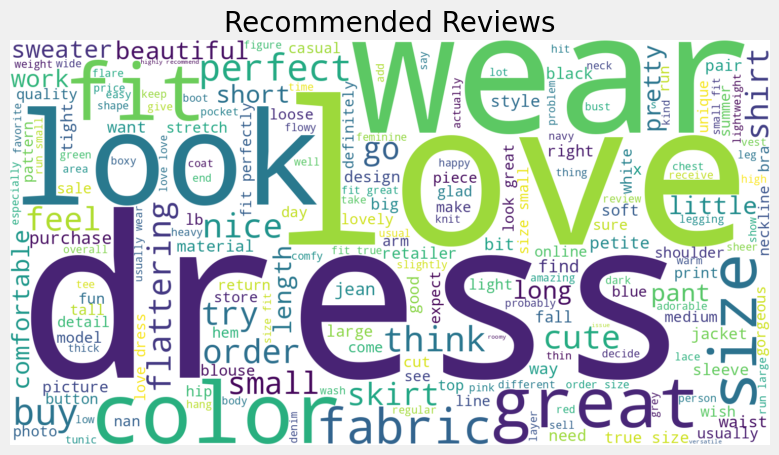

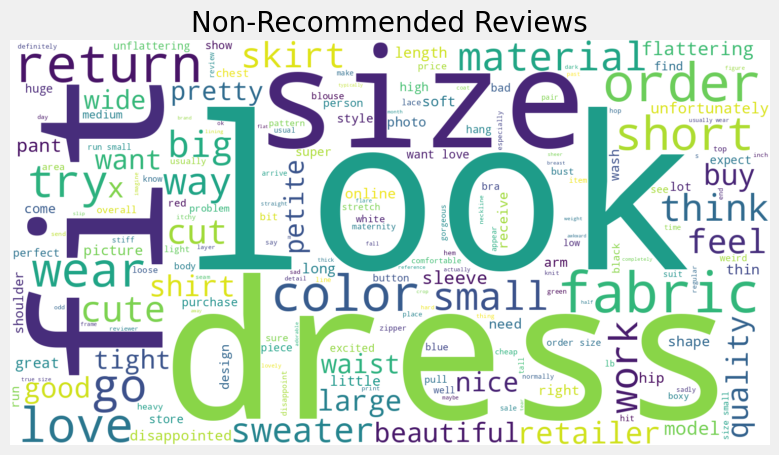

In [12]:
recommend = ' '.join(df[df["RecommendedIND"] == 1]["pr_ReviewText"].dropna())

not_recommend = ' '.join(df[df["RecommendedIND"] == 0]["pr_ReviewText"].dropna())

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([])

def plot_cloud(text, title):
    wordcloud = WordCloud(
        stopwords=STOPWORDS, 
        background_color='white', 
        width=1500, 
        height=800
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

plot_cloud(recommend, "Recommended Reviews")
plot_cloud(not_recommend, "Non-Recommended Reviews")

In [13]:
#Extra analysis that implements frequency counts of non-stop words to show the cross-over of the same words

from collections import Counter

def get_freq_table(text, title, n=20):
    words = [word.lower() for word in text.split() if word.isalpha()]
    filtered_words = [word for word in words if word not in custom_stopwords]
    
    counts = Counter(filtered_words).most_common(n)
    freq_df = pd.DataFrame(counts, columns=['Word', 'Frequency'])
    
    print(f"\nTop {n} words for: {title}")
    return freq_df

rec_freq = get_freq_table(recommend, "Recommended Reviews")
not_rec_freq = get_freq_table(not_recommend, "Non-Recommended Reviews")

display(rec_freq, not_rec_freq)


Top 20 words for: Recommended Reviews

Top 20 words for: Non-Recommended Reviews


,Word,Frequency
0,fit,774
1,size,748
2,love,737
3,wear,720
4,dress,703
5,look,603
6,color,557
7,great,489
8,small,386
9,order,330


,Word,Frequency
0,look,213
1,dress,163
2,size,161
3,fit,148
4,order,110
5,fabric,105
6,love,99
7,small,93
8,return,90
9,wear,87


#### Q2. Using NRCLex, calculate trust, joy, and positive scores for pr_ReviewText. Then calculate the correlation between these scores and RecommendedIND. Which one(s) of the three emotions has a significant correlation with RecommendedIND?

Hint: To calculate the trust score for a text COLUMN

df['trust'] = df.COLUMN.progress_apply(
    lambda x: (lambda t: (t.load_raw_text(str(x)), t.affect_frequencies.get('trust', 0))[1])(NRCLex())
)

## My Answer

In [51]:
df["trust"] = df["pr_ReviewText"].progress_apply(lambda x:(lambda t:(t.load_raw_text(str(x)), 
                                                                        t.affect_frequencies.get("trust", 0))[1])(NRCLex()))

df["joy"] = df["pr_ReviewText"].progress_apply(lambda x:(lambda t:(t.load_raw_text(str(x)), 
                                                                        t.affect_frequencies.get("joy", 0))[1])(NRCLex()))

df["positive"] = df["pr_ReviewText"].progress_apply(lambda x:(lambda t:(t.load_raw_text(str(x)), 
                                                                        t.affect_frequencies.get("positive", 0))[1])(NRCLex()))

100%|██████████| 2000/2000 [00:00<00:00, 4690.18it/s]


<Axes: >

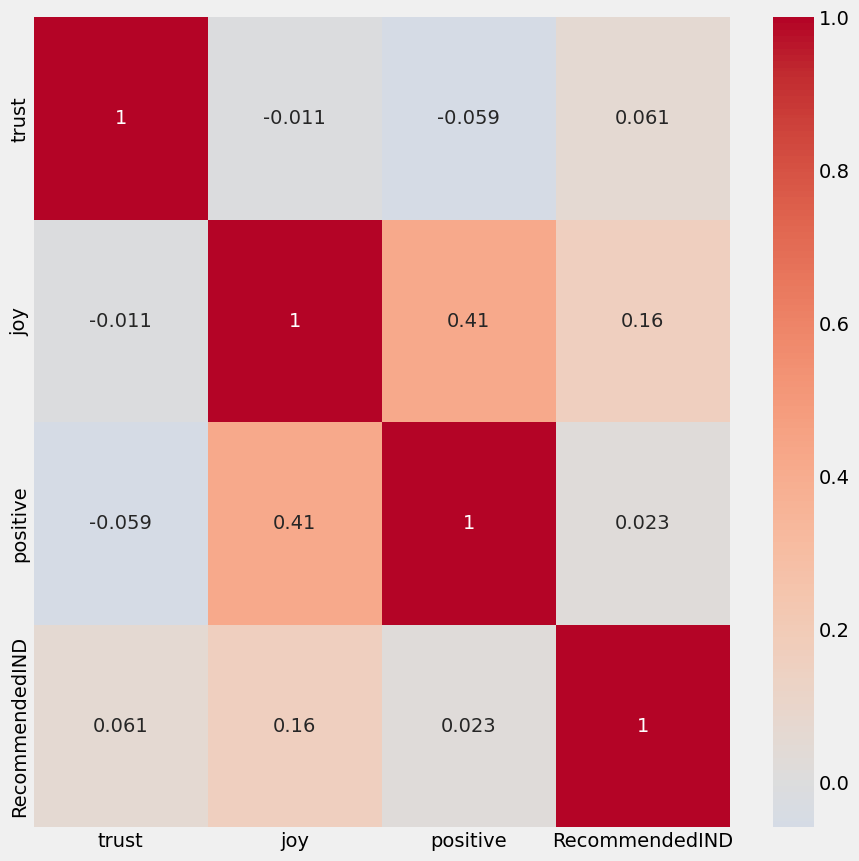

In [54]:
sentiment_scores = df[["trust", "joy", "positive", "RecommendedIND"]]

matrix = sentiment_scores.corr()

sns.heatmap(matrix, annot=True, cmap='coolwarm', center=0)

In [66]:
for sentiment in ["trust", "joy", "positive"]:
    corr, pval = pearsonr(df[sentiment], df["RecommendedIND"])
    sig = 'Statisitcally Significant' if pval < 0.05 else 'Not Statisitcally Significant'
    print(f'{sentiment:10s}: r = {corr:.4f}, p = {pval:.4e}   {sig}')

trust     : r = 0.0607, p = 6.6157e-03   Statisitcally Significant
joy       : r = 0.1600, p = 6.0593e-13   Statisitcally Significant
positive  : r = 0.0233, p = 2.9866e-01   Not Statisitcally Significant


According to the correlation matrix and p-values above, the scores for "joy" and "trust" have statistically significant positive correlations. The sentiment score of "joy" has the highest positive correlation with "RecommendedIND" with a correlation of 0.16.

## Part 2: Supervised Classification

In this part of the assignment, we would like to use NLP and deep learning to build a classifier that can predict whether the customer recommends the product (RecommendedIND = 1) or not (RecommendedIND = 0). 

Here, we would like to use LSTM architecture to build the classifier. We use the pre-processed text data (pr_ReviewText) that we obtained from spaCy. There are a couple of additional steps we need to take before we try LSTM: 

In [16]:
X = df.pr_ReviewText
Y = df.RecommendedIND
le = LabelEncoder()
Y = le.fit_transform(Y)
Y = Y.reshape(-1,1)

Now, we can go ahead and split the data to train and test sets:

In [17]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.8, random_state = 1)

We pre-process the data for the RNN model:

In [18]:
max_words = 8000 # maximum number of words to be used in the analysis
max_len = 50 # maximum length of each document (maximum number of words allowed in each document)
tok = Tokenizer(num_words=max_words) # create the tokenizer
tok.fit_on_texts(X_train) # fit the tokenizer
sequences = tok.texts_to_sequences(X_train) # apply the tokenizer to the data
sequences_matrix = pad_sequences(sequences,maxlen=max_len, padding='post') # trim the sentences

#### Q3. Now, the data is ready to be fed to the deep learning model. Let's go ahead and design our network:

In [19]:
# Clear the previous model:
clear_session()

model = Sequential()
model.add(Input(shape=(max_len,) # size of the input
               ))
model.add(Embedding(max_words, # size of the vocabulary in the data
                    input_length=max_len, # Length of input sequences
                    output_dim = 64 # dimension of the embedding
                   ))
model.add(LSTM(128 # number of units in this layer
              ))
model.add(Normalization())
model.add(Dropout(0.5)) # The Dropout layer randomly sets input units to 0 with a frequency of rate at each step during training time, which helps prevent overfitting. Here we drop 50% of the input units in each step. 
model.add(Dense(1, activation='sigmoid'))

model.summary()

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1777423775.773731      55 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 128)            │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 611,202 (2.33 MB)

 Trainable params: 610,945 (2.33 MB)

 Non-trainable params: 257 (1.01 KB)

Answer the following questions based on the cell above:

#### Q3.A. Which activation function is chosen for the output layer?

## My Answer

The activation function for the output layer is sigmoid.

#### Q3.B. How many hidden layers we have?

## My Answer

The model has 2 hidden layers, this includes the embedding layer but not the input layer, dropout layer, nor the normalization.

#### Q3.C. How many nodes/ units we have in the first hidden layer?

## My Answer

The number of nodes in the first hidden layer is 64.

#### Q3.D. What are the activation functions that we can use in the output layer. Hint: Our target variable is a binary variable and we are working on a classification task. 

## My Answer

The options for an output layer activation function in a binary classification problem are limited. The best practice is to use sigmoid.

Now, we can compile the network:

In [20]:
model.compile(loss='binary_crossentropy', optimizer=RMSprop(learning_rate=1e-4,
                                                         momentum=0.05), metrics=['AUC'])

And finally, we can fit the model:

In [21]:
callback = tf.keras.callbacks.EarlyStopping(monitor="val_AUC", 
                                            patience = 10, # Number of epochs with no improvement after which training will be stopped
                                            min_delta=0.0003, # Minimum change in the monitored quantity to qualify as an improvement
                                            restore_best_weights=True # Whether to restore model weights from the epoch with the best value of the monitored quantity
                                           )

history = model.fit(sequences_matrix, Y_train, # Data to be used for fitting/ training the model
                    epochs=50, # Number times that the learning algorithm will work through the training data
                    batch_size=32, # Number of samples to be used in each iteration
                    verbose=1, # Whether to print the progress 
                    shuffle=True, # Shuffle the data for each epoch
                    validation_split=0.2, # The portion of samples to be used for validation (different from our test data)
                    callbacks = callback
                   )

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - AUC: 0.4929 - loss: 0.6262 - val_AUC: 0.4579 - val_loss: 0.5162
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4672 - loss: 0.5123 - val_AUC: 0.4781 - val_loss: 0.4338
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4704 - loss: 0.5005 - val_AUC: 0.4800 - val_loss: 0.4307
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4933 - loss: 0.4950 - val_AUC: 0.4822 - val_loss: 0.4360
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - AUC: 0.4759 - loss: 0.4971 - val_AUC: 0.4670 - val_loss: 0.4279
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.5071 - loss: 0.4927 - val_AUC: 0.4772 - val_loss: 0.4291
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - AUC: 0.4791 - loss: 0.4967 - val_AUC: 0.4901 - val_loss: 0.4314
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4665 - loss: 0.4967 - val_AUC: 0.4971 - val_loss: 0.4341
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4974

dict_keys(['AUC', 'loss', 'val_AUC', 'val_loss'])


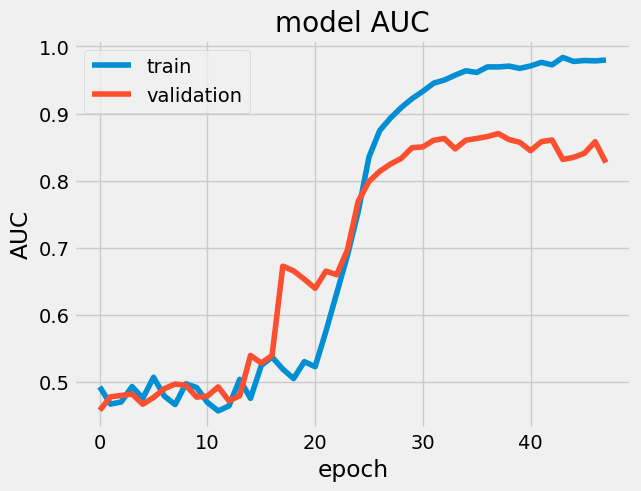

In [23]:
print(history.history.keys())
# "Loss"
plt.plot(history.history['AUC'])
plt.plot(history.history['val_AUC'])
plt.title('model AUC')
plt.ylabel('AUC')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

We can now prepare the test data for the network:

In [24]:
test_sequences = tok.texts_to_sequences(X_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len, padding='post') # trim or pad the sentences

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
AUC Score = 85.967


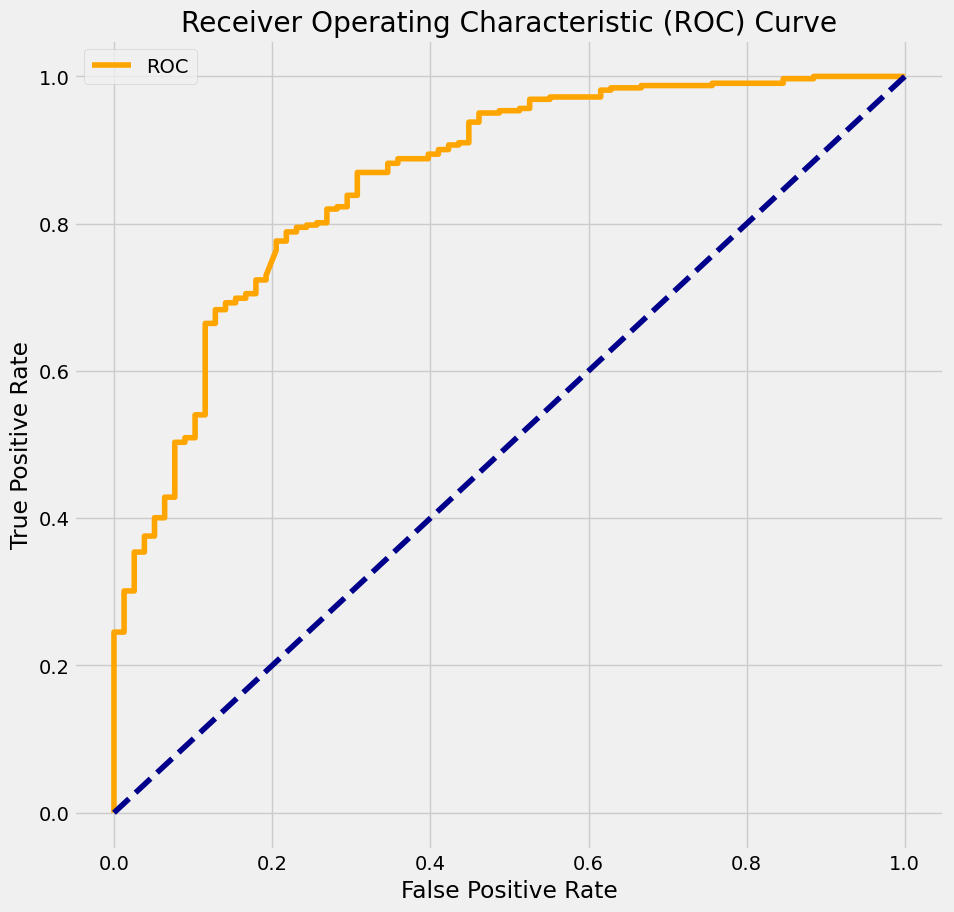

In [25]:
predictionProbabilities = model.predict(test_sequences_matrix)

fpr, tpr, thresholds = roc_curve(Y_test, predictionProbabilities, pos_label = 1)

# calculate scores
lr_auc = roc_auc_score(Y_test, predictionProbabilities)
print('AUC Score = %.3f' % (lr_auc * 100))

# Create the ROC Curve:
def custom_plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

plt.rcParams['figure.figsize'] = [10, 10]
custom_plot_roc_curve(fpr, tpr)

#### Q4. Add a dense layer of size 256 right after the LSTM layer. Use 'relu' activation function, and call this layer 'hidden_dense'. Fit the model. Plot the ROC curve for the new model:

## My Answer

In [44]:
#Added an extra Normalization and Dropout layer (0.5) to preserve the accuracy of the model, since we are adding another hidden layer.

clear_session()

model = Sequential()
model.add(Input(shape=(max_len,) # size of the input
               ))
model.add(Embedding(max_words, # size of the vocabulary in the data
                    input_length=max_len, # Length of input sequences
                    output_dim = 64 # dimension of the embedding
                   ))
model.add(LSTM(128 # number of units in this layer
              ))
model.add(Normalization())
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu', name='hidden_dense'
              ))
model.add(Normalization())
model.add(Dropout(0.5)) # The Dropout layer randomly sets input units to 0 with a frequency of rate at each step during training time, which helps prevent overfitting. Here we drop 50% of the input units in each step. 
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 128)            │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense (Dense)            │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 256)            │           513 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,867 (2.46 MB)

 Trainable params: 644,097 (2.46 MB)

 Non-trainable params: 770 (3.02 KB)

In [37]:
model.compile(loss='binary_crossentropy', optimizer=RMSprop(learning_rate=1e-4,
                                                         momentum=0.05), metrics=['AUC'])

In [38]:
callback = tf.keras.callbacks.EarlyStopping(monitor="val_AUC", 
                                            patience = 20, # Number of epochs with no improvement after which training will be stopped
                                            min_delta=0.0003, # Minimum change in the monitored quantity to qualify as an improvement
                                            restore_best_weights=True # Whether to restore model weights from the epoch with the best value of the monitored quantity
                                           )

history = model.fit(sequences_matrix, Y_train, # Data to be used for fitting/ training the model
                    epochs=50, # Number times that the learning algorithm will work through the training data
                    batch_size=32, # Number of samples to be used in each iteration
                    verbose=1, # Whether to print the progress 
                    shuffle=True, # Shuffle the data for each epoch
                    validation_split=0.2, # The portion of samples to be used for validation (different from our test data)
                    callbacks = callback
                   )

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - AUC: 0.5217 - loss: 0.6502 - val_AUC: 0.4558 - val_loss: 0.5617
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.5067 - loss: 0.5255 - val_AUC: 0.4796 - val_loss: 0.4318
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4753 - loss: 0.5028 - val_AUC: 0.4836 - val_loss: 0.4320
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4683 - loss: 0.5030 - val_AUC: 0.4864 - val_loss: 0.4267
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4908 - loss: 0.4986 - val_AUC: 0.4659 - val_loss: 0.4281
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4711 - loss: 0.5005 - val_AUC: 0.4870 - val_loss: 0.4281
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4899 - loss: 0.4983 - val_AUC: 0.4681 - val_loss: 0.4318
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.5017 - loss: 0.4956 - val_AUC: 0.4671 - val_loss: 0.4245
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4680

dict_keys(['AUC', 'loss', 'val_AUC', 'val_loss'])


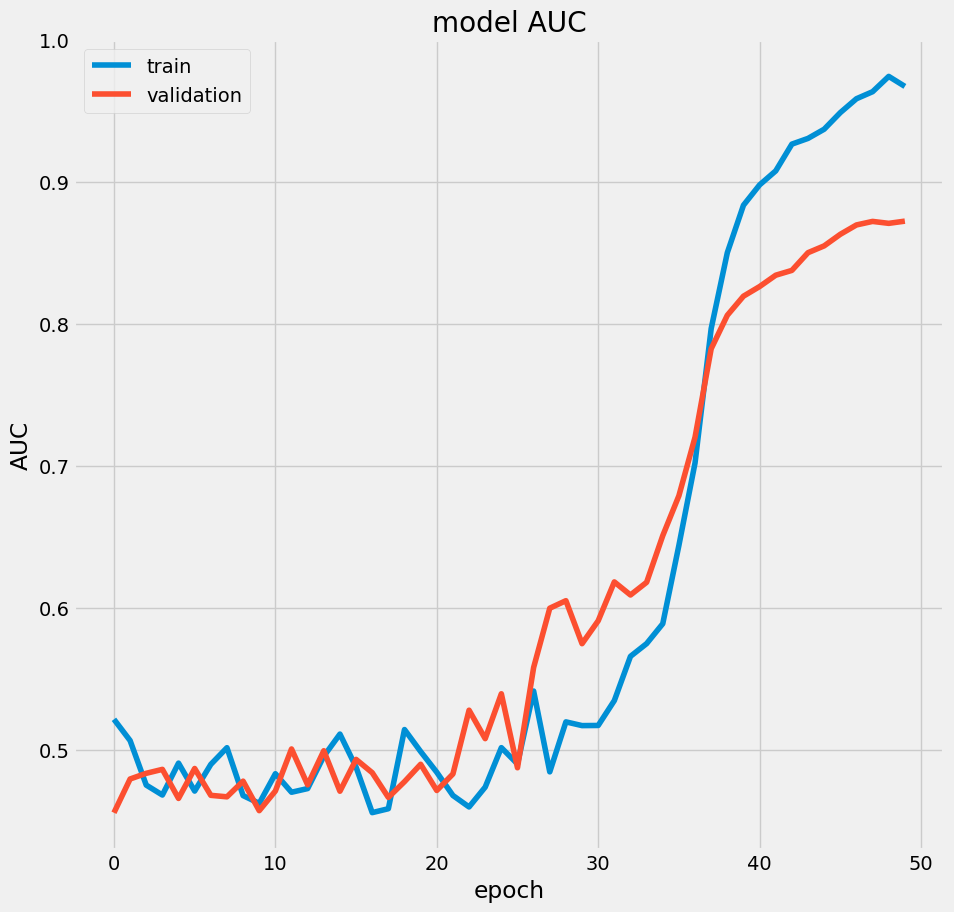

In [39]:
print(history.history.keys())
# "Loss"
plt.plot(history.history['AUC'])
plt.plot(history.history['val_AUC'])
plt.title('model AUC')
plt.ylabel('AUC')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
AUC Score = 84.159


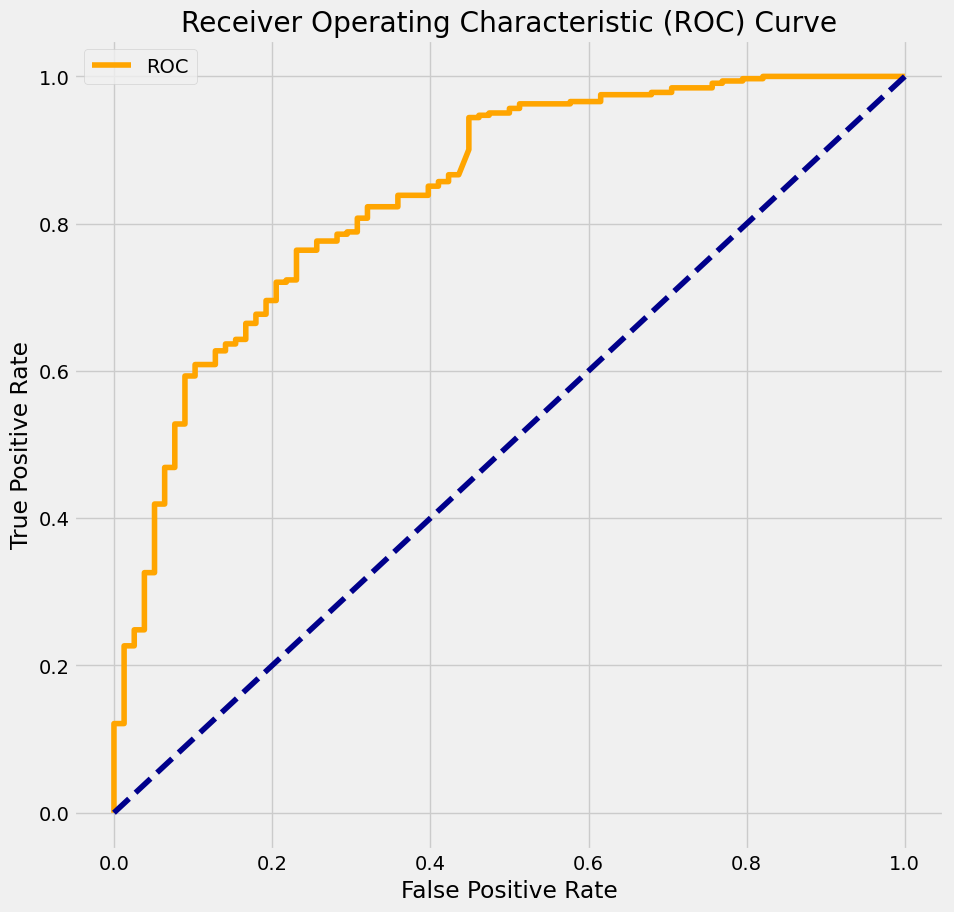

In [40]:
test_sequences = tok.texts_to_sequences(X_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len, padding='post') # trim or pad the sentences

predictionProbabilities = model.predict(test_sequences_matrix)

fpr, tpr, thresholds = roc_curve(Y_test, predictionProbabilities, pos_label = 1)

# calculate scores
lr_auc = roc_auc_score(Y_test, predictionProbabilities)
print('AUC Score = %.3f' % (lr_auc * 100))

# Create the ROC Curve:
def custom_plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

plt.rcParams['figure.figsize'] = [10, 10]
custom_plot_roc_curve(fpr, tpr)

#### Q5: How can NLP help our business?

A. In one paragraph, explain how the e-commerce firm can use the analysis in part 1 to better understand customers' opinions. 

B. In one paragraph, mention (and elaborate on) at least two use cases for this deep learning model. 

## My Answer

### Part A

The e-commerce firm can utilize the analysis in part 1 to understand how natural language reviews from customers impact the sales of products. Implementing the statistical analysis portion allows the company to understand the effect size of the sentiment correlations, as well understand the chances that the effect is not random and is observable in the future. The e-commerce firm could set benchmarks for their existing products to ensure that review sentiment scores do not dip below, the firm could then use these benchmarks to predict the sentiment scores for similar new products, additionally the e-commerce firm could conduct special business tests using the sentiment analysis of customers to identify methods to boost sales and product quality. Further, the e-commerce firm could employ this analysis to understand consumers sentiment towards competitor products to help them monitor the marketplace and potentially achieve a competitive advantage.

### Part B

Use-cases:

1.) predict sales volume of existing products

2.) predict sales volume of new products that are similar to other products

The deep learning model could be employed to predict sales volume of their existing products and potential new products they wish to sell. This model would enable them to determine financial viability of products by accurately predicting which customer will purchase and which one who will not. Since it is a deep learning model, it can handle predicting on large datasets.